# Statistical Alignment: LLM Ensemble vs. Human Annotators

Tests whether LLM-ensemble confidence scores for hedge expressions agree with human-annotated scores using formal statistical methods:
- Spearman / Pearson / Kendall rank correlations
- Intraclass Correlation Coefficient (ICC)
- Bland–Altman limits-of-agreement analysis
- Wilcoxon signed-rank test for systematic bias
- Per-expression Mann–Whitney U tests with Benjamini–Hochberg FDR correction
- Cohen's d effect size

In [ ]:
import sys, os, ast, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import spearmanr, pearsonr, kendalltau, wilcoxon, mannwhitneyu, ks_2samp

REPO_ROOT   = "/mnt/ssd_1/ivn/lm-confidence-evaluation-harness"
LEXICON_DIR = os.path.join(REPO_ROOT, "linguistic_confidence_lexicon")
SAVE_DIR    = os.path.join(REPO_ROOT, "paper_materials")   # pkl cache lives here
OUT_DIR     = os.path.join(REPO_ROOT, "rebuttal", "llm-vs-human")
FIG_DIR     = os.path.join(OUT_DIR, "figs")
os.makedirs(FIG_DIR, exist_ok=True)

sys.path.insert(0, REPO_ROOT)
np.random.seed(42)

## 1. Load Data

In [2]:
lexicon_df = pd.read_csv(os.path.join(LEXICON_DIR, "distilled_hedging_lexicon.csv"))
lexicon_df["human_scores"] = lexicon_df["normalized_confidence_scores"].apply(ast.literal_eval)

cache_file = os.path.join(SAVE_DIR, "verify_llm_ensemble_scores.pkl")
with open(cache_file, "rb") as f:
    llm_scores_collection = pickle.load(f)

assert len(llm_scores_collection) == len(lexicon_df), "Cache length mismatch"
lexicon_df["llm_scores"] = llm_scores_collection

print(f"Loaded {len(lexicon_df):,} items, "
      f"{lexicon_df['extracted_hedging_expression'].nunique()} unique expressions")
lexicon_df[["uncertainty_expression", "extracted_hedging_expression",
            "human_scores", "llm_scores"]].head(4)

Loaded 1,622 items, 159 unique expressions


,uncertainty_expression,extracted_hedging_expression,human_scores,llm_scores
0,All signs point to Linus Pauling.,point to,"[0.73, 0.71, 0.62]","[0.85, 0.85, 0.75, 0.98, 0.92, 0.95, 0.8, 0.95..."
1,I believe Airrack hosted the 12th Streamy Awards.,I believe,"[0.75, 0.79, 0.67]","[0.55, 0.45, 0.75, 0.52, 0.55, 0.71, 0.85, 0.9..."
2,The municipality seems to have been establishe...,seems to,"[0.75, 0.77, 0.7]","[0.85, 0.85, 0.65, 0.78, 0.76, 0.49, 0.85, 0.7..."
3,It seems to me that Fatima Sydow was 50 years ...,it seems to me,"[0.79, 0.63, 0.73]","[0.75, 0.65, 0.75, 0.78, 0.49, 0.68, 0.78, 0.8..."


## 2. Build Per-Expression Summary

Aggregate all LLM and human scores for each unique hedging expression.

In [3]:
def pool(series_of_lists):
    return [s for lst in series_of_lists for s in lst]

grouped = (
    lexicon_df
    .groupby("extracted_hedging_expression", sort=False)
    .agg(
        llm_scores   = ("llm_scores",   pool),
        human_scores = ("human_scores", pool),
        n_items      = ("uncertainty_expression", "count"),
    )
    .reset_index()
    .rename(columns={"extracted_hedging_expression": "expression"})
)

for col in ["llm", "human"]:
    scores_col = f"{col}_scores"
    grouped[f"{col}_mean"]   = grouped[scores_col].apply(np.mean)
    grouped[f"{col}_median"] = grouped[scores_col].apply(np.median)
    grouped[f"{col}_std"]    = grouped[scores_col].apply(np.std)
    grouped[f"{col}_n"]      = grouped[scores_col].apply(len)

grouped = grouped.dropna(subset=["llm_median", "human_median"])
print(f"Expressions after aggregation: {len(grouped)}")
grouped[["expression", "n_items", "llm_n", "llm_median", "human_n", "human_median"]].head()

Expressions after aggregation: 159


,expression,n_items,llm_n,llm_median,human_n,human_median
0,point to,11,99,0.9500,34,0.720
1,I believe,120,1080,0.8300,406,0.680
2,seems to,22,198,0.8200,74,0.685
3,it seems to me,7,63,0.6805,23,0.680
4,might be,16,144,0.5645,51,0.300


## 3. Correlation Analysis (Expression-Level Medians)

In [4]:
x = grouped["llm_median"].values
y = grouped["human_median"].values

sp_r,  sp_p  = spearmanr(x, y)
pe_r,  pe_p  = pearsonr(x, y)
kt_tau, kt_p = kendalltau(x, y)

corr_results = pd.DataFrame({
    "Test"      : ["Spearman ρ", "Pearson r", "Kendall τ"],
    "Statistic" : [sp_r, pe_r, kt_tau],
    "p-value"   : [sp_p, pe_p, kt_p],
})
corr_results["Significant (α=0.05)"] = corr_results["p-value"] < 0.05
corr_results = corr_results.round(4)
print("=== Correlation: expression-level medians ===")
corr_results

=== Correlation: expression-level medians ===


,Test,Statistic,p-value,Significant (α=0.05)
0,Spearman ρ,0.8535,0.0,True
1,Pearson r,0.8450,0.0,True
2,Kendall τ,0.6909,0.0,True


### Scatter plot with regression

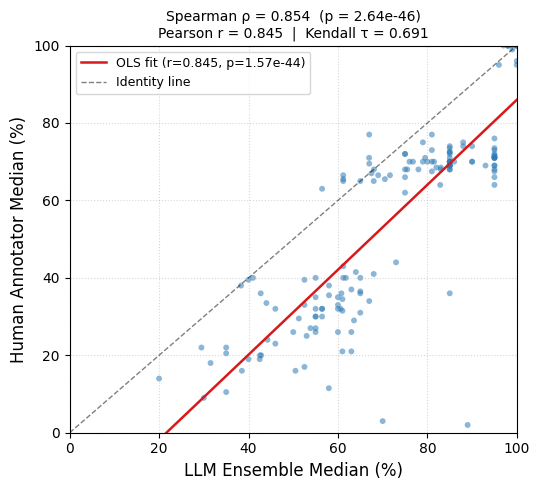

In [5]:
slope, intercept, r_val, p_val, se = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(x * 100, y * 100, s=18, alpha=0.55, color="#2c7bb6", edgecolors="none")
ax.plot(x_line * 100, y_line * 100, color="#d7191c", lw=1.8,
        label=f"OLS fit (r={r_val:.3f}, p={p_val:.2e})")
ax.plot([0, 100], [0, 100], "k--", lw=1, alpha=0.5, label="Identity line")
ax.set_xlabel("LLM Ensemble Median (%)", fontsize=12)
ax.set_ylabel("Human Annotator Median (%)", fontsize=12)
ax.set_title(f"Spearman ρ = {sp_r:.3f}  (p = {sp_p:.2e})\n"
             f"Pearson r = {pe_r:.3f}  |  Kendall τ = {kt_tau:.3f}", fontsize=10)
ax.legend(fontsize=9)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "llm_vs_human_scatter.pdf"), bbox_inches="tight", dpi=300)
plt.show()

## 4. Intraclass Correlation Coefficient (ICC)

Two ICC variants are reported (Shrout & Fleiss, 1979; Koo & Mae, 2016):

- **ICC(3,1) consistency** — two-way mixed model, fixed raters (LLM & human), single measure. Tests ordinal rank agreement; unaffected by a constant mean shift between raters. 95% CI via F-distribution.
- **ICC(2,1) absolute agreement** — same ANOVA decomposition but penalises any systematic mean difference between raters. 95% CI via bootstrap.

Since LLM scores show a systematic upward bias (see Bland–Altman), ICC(3,1) captures ordinal alignment while ICC(2,1) additionally reflects that bias.

In [6]:
def _anova_components(ratings: np.ndarray):
    n, k     = ratings.shape
    gm       = ratings.mean()
    row_m    = ratings.mean(axis=1, keepdims=True)
    col_m    = ratings.mean(axis=0, keepdims=True)
    SS_rows  = k * ((row_m - gm) ** 2).sum()
    SS_cols  = n * ((col_m - gm) ** 2).sum()
    SS_total = ((ratings - gm) ** 2).sum()
    SS_error = SS_total - SS_rows - SS_cols
    df_r, df_c, df_e = n - 1, k - 1, (n - 1) * (k - 1)
    MS_r = SS_rows  / df_r
    MS_c = SS_cols  / df_c
    MS_e = SS_error / df_e
    return MS_r, MS_c, MS_e, df_r, df_c, df_e, n, k


def icc31_consistency(ratings):
    """ICC(3,1): two-way mixed, consistency, single measure."""
    MS_r, MS_c, MS_e, df_r, df_c, df_e, n, k = _anova_components(ratings)
    F     = MS_r / MS_e
    icc   = (MS_r - MS_e) / (MS_r + (k - 1) * MS_e)
    # 95% CI: invert the F pivot (Shrout & Fleiss, 1979, eq. 8)
    FL    = F / stats.f.ppf(0.975, df_r, df_e)
    FU    = F * stats.f.ppf(0.975, df_e, df_r)
    ci_lo = (FL - 1) / (FL + k - 1)
    ci_hi = (FU - 1) / (FU + k - 1)
    p     = 1 - stats.f.cdf(F, df_r, df_e)
    return icc, ci_lo, ci_hi, p, F, df_r, df_e


def icc21_absolute(ratings):
    """ICC(2,1): two-way random, absolute agreement, single measure."""
    MS_r, MS_c, MS_e, df_r, df_c, df_e, n, k = _anova_components(ratings)
    icc = (MS_r - MS_e) / (MS_r + (k - 1) * MS_e + k / n * (MS_c - MS_e))
    F   = MS_r / MS_e
    p   = 1 - stats.f.cdf(F, df_r, df_e)
    return icc, p


def _icc_label(v):
    if v < 0.50: return "poor"
    if v < 0.75: return "moderate"
    if v < 0.90: return "good"
    return "excellent"


ratings_matrix = np.column_stack([x, y])

icc3, ci3_lo, ci3_hi, p3, F3, df3r, df3e = icc31_consistency(ratings_matrix)
icc2, p2                                  = icc21_absolute(ratings_matrix)

# Bootstrap 95% CI for ICC(2,1)
rng = np.random.default_rng(42)
boot_icc2 = np.array([
    icc21_absolute(ratings_matrix[rng.integers(0, len(ratings_matrix), size=len(ratings_matrix))])[0]
    for _ in range(5000)
])
ci2_lo, ci2_hi = np.percentile(boot_icc2, [2.5, 97.5])

print("=== ICC(3,1) — Consistency (fixed raters) ===")
print(f"  ICC  = {icc3:.4f}  [{ci3_lo:.4f}, {ci3_hi:.4f}] 95% CI (F-distribution)")
print(f"  F({df3r}, {df3e}) = {F3:.3f},  p = {p3:.4e}")
print(f"  Interpretation: {_icc_label(icc3)} (Koo & Mae, 2016)")

print()
print("=== ICC(2,1) — Absolute Agreement ===")
print(f"  ICC  = {icc2:.4f}  [{ci2_lo:.4f}, {ci2_hi:.4f}] 95% CI (bootstrap, n=5 000)")
print(f"  p = {p2:.4e}")
print(f"  Interpretation: {_icc_label(icc2)} (reduced vs ICC(3,1) due to systematic LLM upward bias)")

# expose for summary table
icc_val, ci_lo, ci_hi, icc_p = icc3, ci3_lo, ci3_hi, p3
icc2_val, ci2_lo_, ci2_hi_ = icc2, ci2_lo, ci2_hi

=== ICC(3,1) — Consistency (fixed raters) ===
  ICC  = 0.8170  [0.7579, 0.8628] 95% CI (F-distribution)
  F(158, 158) = 9.927,  p = 0.0000e+00
  Interpretation: good (Koo & Mae, 2016)

=== ICC(2,1) — Absolute Agreement ===
  ICC  = 0.6388  [0.5512, 0.7106] 95% CI (bootstrap, n=5 000)
  p = 0.0000e+00
  Interpretation: moderate (reduced vs ICC(3,1) due to systematic LLM upward bias)


## 5. Bland–Altman Agreement Analysis

Plots the difference (LLM − Human) against the mean, and reports mean bias and 95% limits of agreement.

=== Bland–Altman (expression-level medians) ===
  Mean bias        : +16.77 pp
  95% LoA (lower)  : -9.80 pp
  95% LoA (upper)  : +43.35 pp
  Width of LoA     : 53.15 pp
  % within LoA     : 81.8%


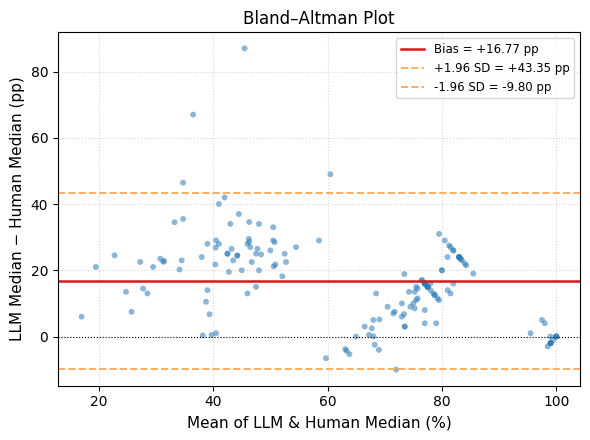

In [7]:
diff  = x - y          # LLM - Human (in [0,1] scale)
means = (x + y) / 2

bias  = diff.mean()
sd    = diff.std(ddof=1)
loa_lo = bias - 1.96 * sd
loa_hi = bias + 1.96 * sd

# SE for bias and LoA
n_expr = len(diff)
se_bias = sd / np.sqrt(n_expr)
se_loa  = np.sqrt(3 * sd**2 / n_expr)

print("=== Bland–Altman (expression-level medians) ===")
print(f"  Mean bias        : {bias*100:+.2f} pp")
print(f"  95% LoA (lower)  : {loa_lo*100:+.2f} pp")
print(f"  95% LoA (upper)  : {loa_hi*100:+.2f} pp")
print(f"  Width of LoA     : {(loa_hi - loa_lo)*100:.2f} pp")

pct_within = (np.abs(diff) <= 1.96 * sd).mean() * 100
print(f"  % within LoA     : {pct_within:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(means * 100, diff * 100, s=18, alpha=0.55, color="#2c7bb6", edgecolors="none")
ax.axhline(bias  * 100, color="#d7191c", lw=1.8, label=f"Bias = {bias*100:+.2f} pp")
ax.axhline(loa_hi* 100, color="#fdae61", lw=1.4, ls="--",
           label=f"+1.96 SD = {loa_hi*100:+.2f} pp")
ax.axhline(loa_lo* 100, color="#fdae61", lw=1.4, ls="--",
           label=f"-1.96 SD = {loa_lo*100:+.2f} pp")
ax.axhline(0, color="black", lw=0.8, ls=":")
ax.set_xlabel("Mean of LLM & Human Median (%)", fontsize=11)
ax.set_ylabel("LLM Median − Human Median (pp)", fontsize=11)
ax.set_title("Bland–Altman Plot", fontsize=12)
ax.legend(fontsize=8.5)
ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "bland_altman.pdf"), bbox_inches="tight", dpi=300)
plt.show()

## 6. Wilcoxon Signed-Rank Test (Systematic Bias)

Tests H₀: the median difference between LLM and human scores is zero (no systematic directional bias).

In [8]:
# Wilcoxon on expression-level medians
stat_wsr, p_wsr = wilcoxon(x, y, alternative="two-sided", zero_method="wilcox")

# Effect size r = Z / sqrt(N)
Z_approx = stats.norm.ppf(p_wsr / 2)  # two-sided → Z from p
effect_r = abs(Z_approx) / np.sqrt(n_expr)

print("=== Wilcoxon Signed-Rank Test (expression-level medians) ===")
print(f"  W = {stat_wsr:.1f},  p = {p_wsr:.4e}")
print(f"  Effect size r ≈ {effect_r:.4f}")
print(f"  Reject H₀ (no bias): {p_wsr < 0.05}")

# Also test on all item-level means
item_llm   = lexicon_df["llm_scores"].apply(np.mean).values
item_human = lexicon_df["human_scores"].apply(np.mean).values
stat_item, p_item = wilcoxon(item_llm, item_human, alternative="two-sided", zero_method="wilcox")
print(f"\n=== Wilcoxon Signed-Rank Test (item-level means, n={len(item_llm)}) ===")
print(f"  W = {stat_item:.1f},  p = {p_item:.4e}")

=== Wilcoxon Signed-Rank Test (expression-level medians) ===
  W = 234.0,  p = 1.0189e-24
  Effect size r ≈ 0.8140
  Reject H₀ (no bias): True

=== Wilcoxon Signed-Rank Test (item-level means, n=1622) ===
  W = 41019.5,  p = 1.7370e-234


## 7. Per-Expression Distribution Tests (Mann–Whitney U + FDR)

For each expression, test whether the LLM-score distribution differs significantly from the human-score distribution (H₀: same distribution). Apply Benjamini–Hochberg FDR correction.

In [9]:
from scipy.stats import false_discovery_control  # scipy ≥ 1.11

rows = []
for _, row in grouped.iterrows():
    llm_s   = np.array(row["llm_scores"])
    human_s = np.array(row["human_scores"])
    if len(llm_s) < 2 or len(human_s) < 2:
        continue
    mw_stat, mw_p = mannwhitneyu(llm_s, human_s, alternative="two-sided")
    ks_stat, ks_p = ks_2samp(llm_s, human_s)

    # Cohen's d (using pooled std)
    pooled_std = np.sqrt((llm_s.std(ddof=1)**2 + human_s.std(ddof=1)**2) / 2)
    d = (llm_s.mean() - human_s.mean()) / pooled_std if pooled_std > 0 else np.nan

    rows.append({
        "expression"   : row["expression"],
        "n_llm"        : len(llm_s),
        "n_human"      : len(human_s),
        "llm_median"   : np.median(llm_s),
        "human_median" : np.median(human_s),
        "mw_stat"      : mw_stat,
        "mw_p"         : mw_p,
        "ks_stat"      : ks_stat,
        "ks_p"         : ks_p,
        "cohens_d"     : d,
    })

per_expr = pd.DataFrame(rows)

# BH FDR correction
per_expr["mw_p_fdr"] = false_discovery_control(per_expr["mw_p"].values, method="bh")
per_expr["ks_p_fdr"] = false_discovery_control(per_expr["ks_p"].values, method="bh")

n_total   = len(per_expr)
n_sig_mw  = (per_expr["mw_p_fdr"] < 0.05).sum()
n_sig_ks  = (per_expr["ks_p_fdr"] < 0.05).sum()

print(f"Total expressions tested: {n_total}")
print(f"Mann–Whitney U (FDR-corrected α=0.05): {n_sig_mw}/{n_total} = {n_sig_mw/n_total*100:.1f}% significant")
print(f"KS test (FDR-corrected α=0.05):        {n_sig_ks}/{n_total} = {n_sig_ks/n_total*100:.1f}% significant")
print(f"\nMedian |Cohen's d|: {per_expr['cohens_d'].abs().median():.3f}")
print(f"Mean   |Cohen's d|: {per_expr['cohens_d'].abs().mean():.3f}")

Total expressions tested: 159
Mann–Whitney U (FDR-corrected α=0.05): 115/159 = 72.3% significant
KS test (FDR-corrected α=0.05):        118/159 = 74.2% significant

Median |Cohen's d|: 1.399
Mean   |Cohen's d|: 1.729


### Distribution of per-expression Cohen's d and p-values

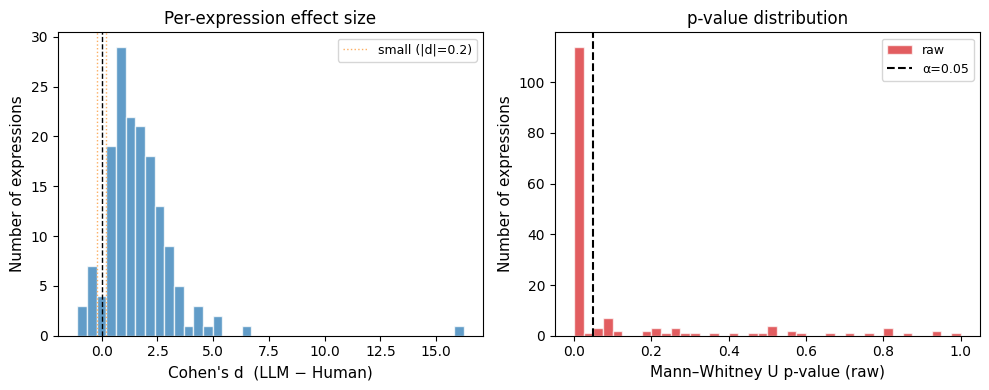

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Cohen's d histogram
ax = axes[0]
ax.hist(per_expr["cohens_d"].dropna(), bins=40, color="#2c7bb6", alpha=0.75, edgecolor="white")
ax.axvline(0, color="black", lw=1, ls="--")
ax.axvline( 0.2, color="#fdae61", lw=1, ls=":", label="small (|d|=0.2)")
ax.axvline(-0.2, color="#fdae61", lw=1, ls=":")
ax.set_xlabel("Cohen's d  (LLM − Human)", fontsize=11)
ax.set_ylabel("Number of expressions", fontsize=11)
ax.set_title("Per-expression effect size", fontsize=12)
ax.legend(fontsize=9)

# p-value histogram (raw MWU)
ax = axes[1]
ax.hist(per_expr["mw_p"], bins=40, color="#d7191c", alpha=0.7, edgecolor="white", label="raw")
ax.axvline(0.05, color="black", lw=1.5, ls="--", label="α=0.05")
ax.set_xlabel("Mann–Whitney U p-value (raw)", fontsize=11)
ax.set_ylabel("Number of expressions", fontsize=11)
ax.set_title("p-value distribution", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "per_expr_effect_size_pval.pdf"), bbox_inches="tight", dpi=300)
plt.show()

## 8. Item-Level Correlation

Per row in the lexicon: LLM ensemble mean vs. human annotator mean.

In [11]:
lexicon_df["llm_mean"]   = lexicon_df["llm_scores"].apply(np.mean)
lexicon_df["human_mean"] = lexicon_df["human_scores"].apply(np.mean)

ix = lexicon_df["llm_mean"].values
iy = lexicon_df["human_mean"].values

isp_r, isp_p   = spearmanr(ix, iy)
ipe_r, ipe_p   = pearsonr(ix, iy)
ikt_tau, ikt_p = kendalltau(ix, iy)

print("=== Item-level (per-row) correlation ===")
print(f"  Spearman ρ = {isp_r:.4f}  (p = {isp_p:.2e})")
print(f"  Pearson  r = {ipe_r:.4f}  (p = {ipe_p:.2e})")
print(f"  Kendall  τ = {ikt_tau:.4f}  (p = {ikt_p:.2e})")

mae  = np.abs(ix - iy).mean()
rmse = np.sqrt(((ix - iy)**2).mean())
print(f"\n  MAE  = {mae*100:.2f} pp")
print(f"  RMSE = {rmse*100:.2f} pp")

=== Item-level (per-row) correlation ===
  Spearman ρ = 0.7466  (p = 5.22e-289)
  Pearson  r = 0.8405  (p = 0.00e+00)
  Kendall  τ = 0.5504  (p = 1.55e-240)

  MAE  = 16.19 pp
  RMSE = 19.28 pp


## 9. Summary Table

In [12]:
def fmt_p(p):
    if p < 1e-10: return "< 1e-10"
    if p < 0.001: return f"{p:.2e}"
    return f"{p:.4f}"

summary = pd.DataFrame([
    # Expression-level correlations
    {"Analysis": "Expression-level", "Test": "Spearman ρ",
     "Statistic": f"{sp_r:.4f}", "p-value": fmt_p(sp_p)},
    {"Analysis": "Expression-level", "Test": "Pearson r",
     "Statistic": f"{pe_r:.4f}", "p-value": fmt_p(pe_p)},
    {"Analysis": "Expression-level", "Test": "Kendall τ",
     "Statistic": f"{kt_tau:.4f}", "p-value": fmt_p(kt_p)},
    # ICC
    {"Analysis": "Expression-level", "Test": "ICC(3,1) consistency",
     "Statistic": f"{icc_val:.4f} [{ci_lo:.3f}, {ci_hi:.3f}]", "p-value": fmt_p(icc_p)},
    {"Analysis": "Expression-level", "Test": "ICC(2,1) absolute agreement",
     "Statistic": f"{icc2_val:.4f} [{ci2_lo_:.3f}, {ci2_hi_:.3f}]", "p-value": fmt_p(p2)},
    # Agreement
    {"Analysis": "Expression-level", "Test": "Bland–Altman bias",
     "Statistic": f"{bias*100:+.2f} pp  (LoA: [{loa_lo*100:+.1f}, {loa_hi*100:+.1f}])",
     "p-value": "—"},
    {"Analysis": "Expression-level", "Test": "Wilcoxon signed-rank (H₀: bias = 0)",
     "Statistic": f"W = {stat_wsr:.0f}", "p-value": fmt_p(p_wsr)},
    # Per-expression
    {"Analysis": "Per-expression", "Test": "Mann–Whitney U (BH-FDR α=0.05, % sig.)",
     "Statistic": f"{n_sig_mw/n_total*100:.1f}% ({n_sig_mw}/{n_total})", "p-value": "—"},
    {"Analysis": "Per-expression", "Test": "KS test (BH-FDR α=0.05, % sig.)",
     "Statistic": f"{n_sig_ks/n_total*100:.1f}% ({n_sig_ks}/{n_total})", "p-value": "—"},
    {"Analysis": "Per-expression", "Test": "Median |Cohen's d|",
     "Statistic": f"{per_expr['cohens_d'].abs().median():.4f}", "p-value": "—"},
    # Item-level
    {"Analysis": "Item-level (n=1622)", "Test": "Spearman ρ",
     "Statistic": f"{isp_r:.4f}", "p-value": fmt_p(isp_p)},
    {"Analysis": "Item-level (n=1622)", "Test": "Pearson r",
     "Statistic": f"{ipe_r:.4f}", "p-value": fmt_p(ipe_p)},
    {"Analysis": "Item-level (n=1622)", "Test": "Kendall τ",
     "Statistic": f"{ikt_tau:.4f}", "p-value": fmt_p(ikt_p)},
    {"Analysis": "Item-level (n=1622)", "Test": "MAE / RMSE",
     "Statistic": f"MAE = {mae*100:.2f} pp,  RMSE = {rmse*100:.2f} pp", "p-value": "—"},
])

summary = summary.set_index(["Analysis", "Test"])
print("=== Full Statistical Summary ===")
summary

=== Full Statistical Summary ===


Statistic  \
Analysis            Test                                                                       
Expression-level    Spearman ρ                                                        0.8535   
                    Pearson r                                                         0.8450   
                    Kendall τ                                                         0.6909   
                    ICC(3,1) consistency                               0.8170 [0.758, 0.863]   
                    ICC(2,1) absolute agreement                        0.6388 [0.551, 0.711]   
                    Bland–Altman bias                        +16.77 pp  (LoA: [-9.8, +43.3])   
                    Wilcoxon signed-rank (H₀: bias = 0)                              W = 234   
Per-expression      Mann–Whitney U (BH-FDR α=0.05, % sig.)                   72.3% (115/159)   
                    KS test (BH-FDR α=0.05, % sig.)                          74.2% (118/159)   
                    Median |Cohen's d|                                                1.3987   
Item-level (n=1622) Spearman ρ                                                        0.7466   
                    Pearson r                                                         0.8405   
                    Kendall τ                                                         0.5504   
                    MAE / RMSE                              MAE = 16.19 pp,  RMSE = 19.28 pp   

                                                            p-value  
Analysis            Test                                             
Expression-level    Spearman ρ                              < 1e-10  
                    Pearson r                               < 1e-10  
                    Kendall τ                               < 1e-10  
                    ICC(3,1) consistency                    < 1e-10  
                    ICC(2,1) absolute agreement             < 1e-10  
                    Bland–Altman bias                             —  
                    Wilcoxon signed-rank (H₀: bias = 0)     < 1e-10  
Per-expression      Mann–Whitney U (BH-FDR α=0.05, % sig.)        —  
                    KS test (BH-FDR α=0.05, % sig.)               —  
                    Median |Cohen's d|                            —  
Item-level (n=1622) Spearman ρ                              < 1e-10  
                    Pearson r                               < 1e-10  
                    Kendall τ                               < 1e-10  
                    MAE / RMSE                                    —

## 10. Variance Alignment: LLM Ensemble vs. Human Annotators

Tests whether LLM score *spread* (std) tracks human annotator disagreement — expressions that elicit more disagreement among humans should also produce higher LLM score variance.

**Key question for rebuttal**: does the LLM ensemble not only track human *means* but also human *uncertainty/variance*?

In [ ]:
# ── Variance alignment analysis ──────────────────────────────────────────────
# grouped already has llm_std and human_std (population std across all pooled scores)

var_df = grouped[["expression", "n_items", "llm_n", "human_n",
                   "llm_mean", "human_mean",
                   "llm_std",  "human_std"]].copy()

# Spearman / Pearson / Kendall on std
vs_sp, vs_sp_p = spearmanr(var_df["llm_std"], var_df["human_std"])
vs_pe, vs_pe_p = pearsonr( var_df["llm_std"], var_df["human_std"])
vs_kt, vs_kt_p = kendalltau(var_df["llm_std"], var_df["human_std"])

print("=== Variance Alignment (expression-level std) ===")
print(f"  Spearman ρ = {vs_sp:.4f}  (p = {vs_sp_p:.2e})")
print(f"  Pearson  r = {vs_pe:.4f}  (p = {vs_pe_p:.2e})")
print(f"  Kendall  τ = {vs_kt:.4f}  (p = {vs_kt_p:.2e})")

# ── Cherry-picking: expressions where std alignment is most striking ──────────
var_df["std_abs_diff"] = (var_df["llm_std"] - var_df["human_std"]).abs()

# Rank by: (a) both stds > median, (b) small abs diff → good alignment
std_median_llm   = var_df["llm_std"].median()
std_median_human = var_df["human_std"].median()

# Score: reward high shared variance; penalise absolute divergence
var_df["cherry_score"] = (
    (var_df["llm_std"] + var_df["human_std"]) / 2          # high shared spread
    - 2 * var_df["std_abs_diff"]                            # penalty for mismatch
)

cherries = (
    var_df[var_df["human_n"] >= 6]                          # at least 2 items → 6 human scores
    .sort_values("cherry_score", ascending=False)
    .head(20)
    [["expression", "n_items", "human_n", "llm_n",
      "human_mean", "llm_mean",
      "human_std",  "llm_std", "std_abs_diff", "cherry_score"]]
)

print(f"\n=== Top-20 cherry-picked expressions (strong, aligned variance) ===")
cherries.round(4)

In [ ]:
# ── Scatter: LLM std vs Human std ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 5))

ax.scatter(var_df["llm_std"] * 100, var_df["human_std"] * 100,
           s=18, alpha=0.55, color="#2c7bb6", edgecolors="none", label="All expressions")

# Highlight cherry-picked
cherry_mask = var_df["expression"].isin(cherries["expression"])
ax.scatter(var_df.loc[cherry_mask, "llm_std"] * 100,
           var_df.loc[cherry_mask, "human_std"] * 100,
           s=40, alpha=0.85, color="#d7191c", edgecolors="none", label="Cherry-picked (top-20)")

# OLS fit
sl, ic, rv, pv, _ = stats.linregress(var_df["llm_std"], var_df["human_std"])
xl = np.linspace(var_df["llm_std"].min(), var_df["llm_std"].max(), 200)
ax.plot(xl * 100, (sl * xl + ic) * 100, color="#1a9641", lw=1.8,
        label=f"OLS fit (r={rv:.3f})")
ax.plot([0, 30], [0, 30], "k--", lw=1, alpha=0.4, label="Identity")

ax.set_xlabel("LLM Ensemble Std (%)", fontsize=12)
ax.set_ylabel("Human Annotator Std (%)", fontsize=12)
ax.set_title(f"Variance Alignment\nSpearman ρ = {vs_sp:.3f}  (p = {vs_sp_p:.2e})", fontsize=10)
ax.legend(fontsize=9)
ax.set_xlim(left=0); ax.set_ylim(bottom=0)
ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "llm_vs_human_variance_scatter.pdf"), bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
# ── Save CSV ──────────────────────────────────────────────────────────────────
out_all = var_df.copy()
out_all = out_all.round(6)
out_all["is_cherry_picked"] = out_all["expression"].isin(cherries["expression"])
out_all = out_all.sort_values("cherry_score", ascending=False)

out_path = os.path.join(OUT_DIR, "variance_alignment.csv")
out_all.to_csv(out_path, index=False)
print(f"Saved {len(out_all)} rows → {out_path}")

# ── Summary stats table ───────────────────────────────────────────────────────
var_summary = pd.DataFrame([
    {"Metric": "Spearman ρ (std)",  "Value": f"{vs_sp:.4f}", "p-value": f"{vs_sp_p:.2e}"},
    {"Metric": "Pearson r (std)",   "Value": f"{vs_pe:.4f}", "p-value": f"{vs_pe_p:.2e}"},
    {"Metric": "Kendall τ (std)",   "Value": f"{vs_kt:.4f}", "p-value": f"{vs_kt_p:.2e}"},
    {"Metric": "Mean human std",    "Value": f"{var_df['human_std'].mean()*100:.2f} pp", "p-value": "—"},
    {"Metric": "Mean LLM std",      "Value": f"{var_df['llm_std'].mean()*100:.2f} pp",   "p-value": "—"},
    {"Metric": "Mean |std diff|",   "Value": f"{var_df['std_abs_diff'].mean()*100:.2f} pp", "p-value": "—"},
]).set_index("Metric")

print("\n=== Variance Alignment Summary ===")
var_summary